# Decomposição da Série Temporal

Nesta etapa será realizada a decomposição da série temporal de Trocas de Óleo da MecâniQA, buscando isolar os componentes de Tendência, Sazonalidade e Ruído.

Com base no Brainstorm da equipe, foi adotado:

- Modelo: Aditivo
- Periodicidade: 7 dias

## 1. Importação das bibliotecas

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Carregamento e preparação do dataset

In [2]:
data_path = next((
    path for path in [
        Path("data/mecaniqa_dataset.xlsx"),
        Path("../data/mecaniqa_dataset.xlsx"),
    ]
    if path.exists()
), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset não encontrado. Abra o projeto pela pasta mecaniQA-salvador."
    )

df = pd.read_excel(data_path)
df.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


In [3]:
df["Data"] = pd.to_datetime(df["Data"])

df = df.sort_values("Data")
df.set_index("Data", inplace=True)

df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


## 3. Série temporal de Trocas de Óleo

In [4]:
serie_trocas_oleo = df["Trocas_Oleo"].resample("D").sum(min_count=1)

serie_trocas_oleo.head()

Data
2024-01-01    11.0
2024-01-02     9.0
2024-01-03    12.0
2024-01-04    15.0
2024-01-05    25.0
Freq: D, Name: Trocas_Oleo, dtype: float64

## 4. Decomposição da série temporal

In [5]:
# A decomposição exige uma série completa. A interpolação é usada apenas
# nesta análise descritiva; os baselines abaixo usam somente dados passados.
serie_decomposicao = serie_trocas_oleo.interpolate(method="time")

decomposicao = seasonal_decompose(
    serie_decomposicao,
    model="additive",
    period=7
)

decomposicao

## 5. Visualização dos componentes

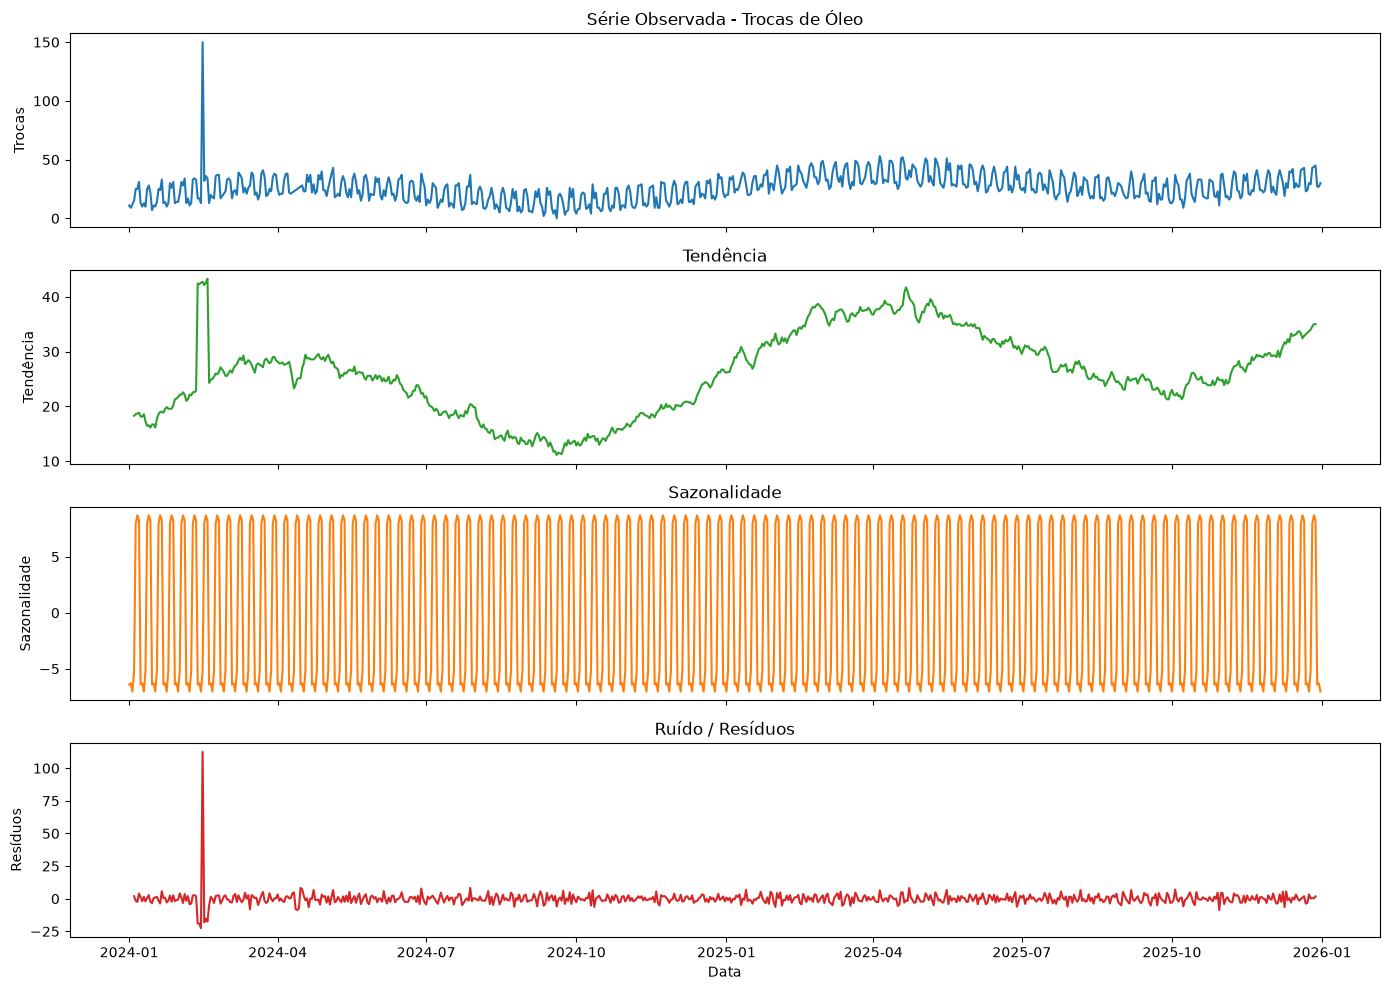

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomposicao.observed, color="#1f77b4")
axes[0].set_title("Série Observada - Trocas de Óleo")
axes[0].set_ylabel("Trocas")

axes[1].plot(decomposicao.trend, color="#2ca02c")
axes[1].set_title("Tendência")
axes[1].set_ylabel("Tendência")

axes[2].plot(decomposicao.seasonal, color="#ff7f0e")
axes[2].set_title("Sazonalidade")
axes[2].set_ylabel("Sazonalidade")

axes[3].plot(decomposicao.resid, color="#d62728")
axes[3].set_title("Ruído / Resíduos")
axes[3].set_ylabel("Resíduos")
axes[3].set_xlabel("Data")

plt.tight_layout()
plt.show()

## 6. Modelos de baseline protegidos contra Data Leakage

### Decisões do brainstorm de 02/09

1. **Armadilha do futuro:** aplicamos `shift(1)` antes das previsões e das janelas móveis. Assim, a previsão do instante `t` começa no valor observado em `t-1` e nunca usa `t+1`. Valores ausentes no histórico são preenchidos com `ffill`, que também consulta apenas o passado.
2. **Complexidade x simplicidade:** cada baseline é uma função Python curta que recebe a série e devolve outra série indexada pelas mesmas datas. Essa estrutura direta facilita comparar o Naive e diferentes janelas sem introduzir classes desnecessárias.

O modelo Naive repete o valor do dia anterior. A média móvel usa os sete valores anteriores ao dia previsto.

In [7]:
def modelo_naive(serie):
    return serie.shift(1)


def modelo_media_movel(serie, janela=7):
    return serie.shift(1).rolling(window=janela).mean()


# ffill preserva a ordem temporal: um vazio recebe o último valor conhecido.
serie_historica = serie_trocas_oleo.ffill()
previsao_naive = modelo_naive(serie_historica)
previsao_media_movel_7 = modelo_media_movel(serie_historica, janela=7)

previsoes_baseline = pd.DataFrame({
    "Real": serie_trocas_oleo,
    "Naive": previsao_naive,
    "Média móvel (7 dias)": previsao_media_movel_7,
})
previsoes_baseline.head(10)

,Real,Naive,Média móvel (7 dias)
Data,,,
2024-01-01,11.0,NaN,NaN
2024-01-02,9.0,11.0,NaN
2024-01-03,12.0,9.0,NaN
2024-01-04,15.0,12.0,NaN
2024-01-05,25.0,15.0,NaN
2024-01-06,25.0,25.0,NaN
2024-01-07,31.0,25.0,NaN
2024-01-08,13.0,31.0,18.285714
2024-01-09,10.0,13.0,18.571429


### Comparação visual dos baselines

O recorte final deixa o deslocamento mais legível, enquanto os cálculos permanecem disponíveis para toda a série.

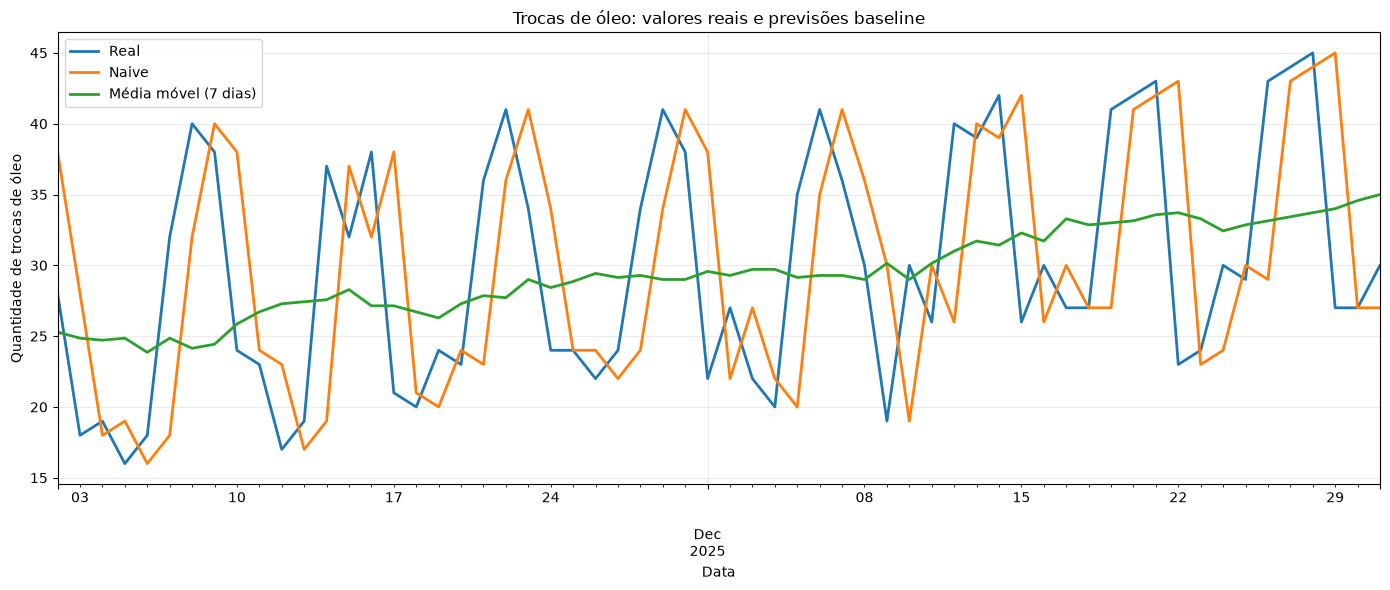

In [8]:
ax = previsoes_baseline.tail(60).plot(figsize=(14, 6), linewidth=2)
ax.set_title("Trocas de óleo: valores reais e previsões baseline")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade de trocas de óleo")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Validação temporal — atividade de 09/09

Usamos cinco folds de treino expansivo e previsões de um dia à frente. O histórico é atualizado após cada observação, mantendo shift(1), ffill e média móvel de sete dias. Os dois modelos são avaliados nas mesmas datas; reais ausentes são excluídos, e zeros são excluídos somente do MAPE. MAE e RMSE medem trocas por dia, não litros. As decisões e a interpretação estão no README.


In [9]:
import sys

# Permite executar a partir da raiz ou da pasta notebooks.
raiz = next(p.resolve() for p in [Path.cwd(), Path.cwd().parent]
            if (p / 'validacao_baselines.py').exists())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from validacao_baselines import avaliar_baselines, imprimir_boletim

metricas_por_fold, resumo_baselines, previsoes_validacao = avaliar_baselines(serie_trocas_oleo)
imprimir_boletim(metricas_por_fold, resumo_baselines)


Validação temporal: previsão diária de um passo à frente
 Fold               Modelo Início treino Fim treino Início teste  Fim teste  Dias excluídos    MAE   RMSE  MAPE (%)  Dias avaliados  Dias MAPE
    1                Naive    2024-01-01 2024-05-05   2024-05-06 2024-09-03               0 6.8678 9.0750   42.5496             121        121
    1 Média móvel (7 dias)    2024-01-01 2024-05-05   2024-05-06 2024-09-03               0 7.4026 8.0631   47.7869             121        121
    2                Naive    2024-01-01 2024-09-03   2024-09-04 2025-01-02               0 6.6116 9.0745   51.0218             121        120
    2 Média móvel (7 dias)    2024-01-01 2024-09-03   2024-09-04 2025-01-02               0 7.3920 8.0375   59.7630             121        120
    3                Naive    2024-01-01 2025-01-02   2025-01-03 2025-05-03               0 6.3719 8.3334   18.9546             121        121
    3 Média móvel (7 dias)    2024-01-01 2025-01-02   2025-01-03 2025-05-03          